In [ ]:
!pip3 install langchain-openai langchain-huggingface langchain-community langchain-text-splitters langchain-classic langchain-core langgraph faiss-cpu tavily-python wikipedia arxiv sentence-transformers pypdf streamlit pyngrok

In [ ]:
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv()

@tool
def calculator(expression: str) -> str:
    """Does math calculations. Pass a mathematical expression like '25 * 4'."""
    try:
        allowed_chars = set("0123456789+-*/(). ")
        if all(c in allowed_chars for c in expression):
            return str(eval(expression))
        else:
            return "Error: Invalid characters in expression"
    except Exception as e:
        return f"Error in calculation: {e}"

@tool
def text_length(text: str) -> str:
    """Counts the length of the provided text in characters."""
    return f"Length: {len(text)} characters"

tools = [calculator, text_length]
api_key=""
llm = ChatOpenAI(
    model="openai/gpt-4o",
    openai_api_key=api_key,#=os.getenv("OPENROUTER_API_KEY"),
    openai_api_base="https://openrouter.ai/api/v1",
    temperature=0
)


agent = create_react_agent(llm, tools)

def run(query: str) -> str:
    response = agent.invoke({"messages": [HumanMessage(content=query)]})
    for msg in reversed(response["messages"]):
        if isinstance(msg, AIMessage) and msg.content:
            return msg.content
    return "No response"

def main():
    print("\n=== Test 1: Calculator ===")
    print(run("What is 25 * 4?"))

    print("\n=== Test 2: Text Length ===")
    print(run("How long is the text 'Hello World'?"))

    print("\n=== Test 3: General Knowledge ===")
    print(run("Who is Mark Zuckerberg?"))

if __name__ == "__main__":
    main()


'''
Call 1 — GPT-4o decides which tool and what input
Call 2 — GPT-4o formats the tool result into a human answer

'''


'''
**ReAct stands for Reasoning + Acting.**

It's just a loop:
```
Reason  → which tool should I use?
Act     → call the tool
Reason  → what does the result mean?
Act     → call another tool if needed, or give final answer
```

---

**In your code specifically, the ReAct agent is:**

The thing that manages the back and forth between GPT-4o and your tools. It's the middleman.
```
You → ReAct Agent → GPT-4o (call 1) → calculator runs → GPT-4o (call 2) → You

'''

/tmp/ipykernel_15539/4169962369.py:37: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools)



=== Test 1: Calculator ===
The result of \(25 \times 4\) is 100.

=== Test 2: Text Length ===
The text "Hello World" is 11 characters long.

=== Test 3: General Knowledge ===
Mark Zuckerberg is an American technology entrepreneur and philanthropist best known for co-founding Facebook, the world's largest social media platform. Born on May 14, 1984, in White Plains, New York, Zuckerberg developed an interest in computers and programming at an early age. He attended Harvard University, where he launched Facebook in 2004 with his college roommates. The platform quickly gained popularity, expanding beyond college campuses to become a global social networking service.

Zuckerberg has served as the CEO and chairman of Meta Platforms, Inc. (formerly Facebook, Inc.), overseeing its growth and expansion into various areas, including virtual reality and artificial intelligence. He is also known for his philanthropic efforts, particularly through the Chan Zuckerberg Initiative, which he founded 

"\n**ReAct stands for Reasoning + Acting.**\n\nIt's just a loop:\n```\nReason  → which tool should I use?\nAct     → call the tool\nReason  → what does the result mean?\nAct     → call another tool if needed, or give final answer\n```\n\n---\n\n**In your code specifically, the ReAct agent is:**\n\nThe thing that manages the back and forth between GPT-4o and your tools. It's the middleman.\n```\nYou → ReAct Agent → GPT-4o (call 1) → calculator runs → GPT-4o (call 2) → You\n\n"

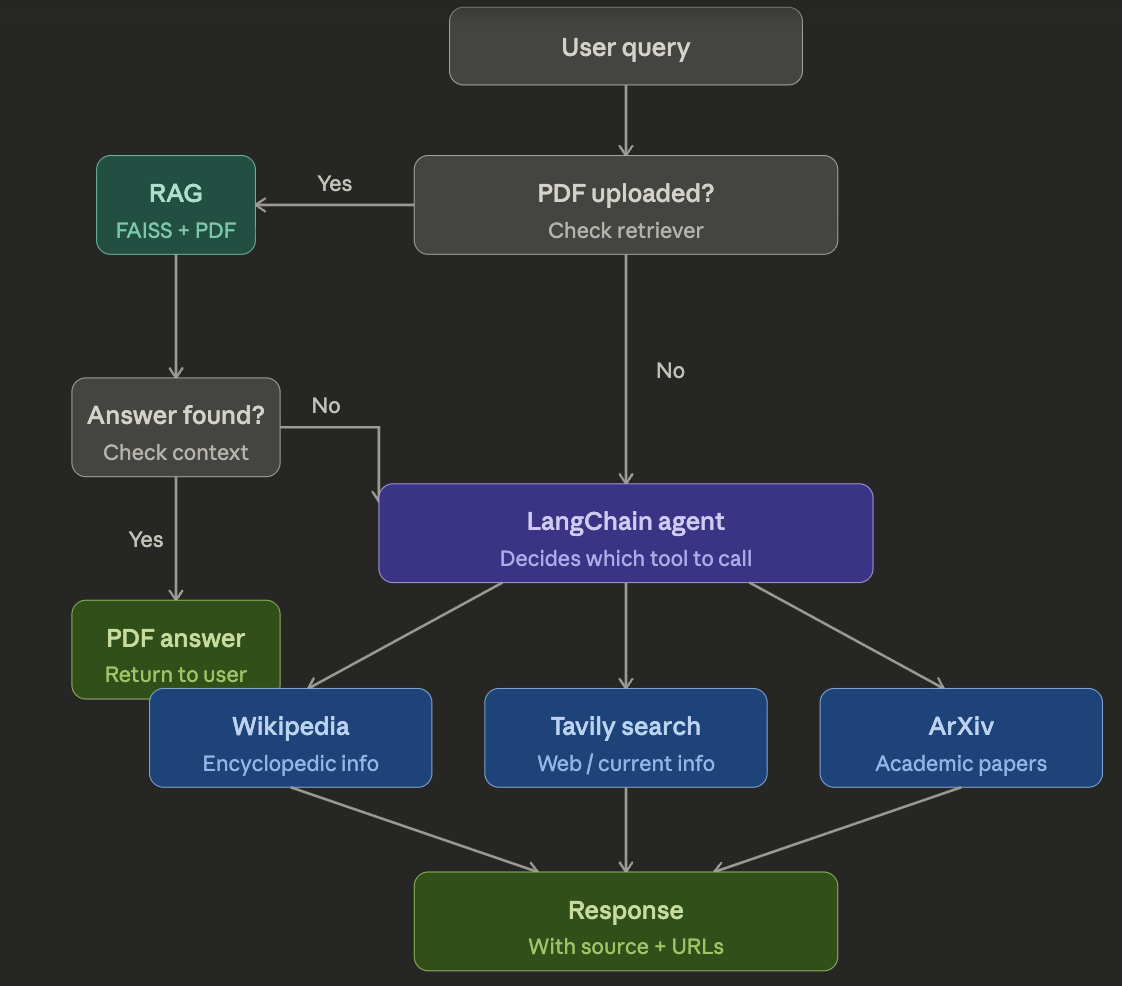

In [12]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
# !pip install langchain-openai langchain-huggingface langchain-community \
#             langchain-text-splitters langchain-classic langchain-core \
#             langgraph faiss-cpu tavily-python wikipedia arxiv \
#             sentence-transformers pypdf streamlit pyngrok

# ============================================================
# CELL 2 — Write the Streamlit app to a file
# ============================================================

app_code = '''
import streamlit as st
import os
import shutil
import tempfile

from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.prebuilt import create_react_agent
from tavily import TavilyClient
import wikipedia
import arxiv

st.set_page_config(page_title="Agentic RAG", layout="wide")
st.title("🔍 Agentic RAG with Tavily + GPT-4o + HuggingFace Embeddings")

st.sidebar.header("API Keys")
openrouter_key = st.sidebar.text_input("OpenRouter API Key", type="password")
tavily_key = st.sidebar.text_input("Tavily API Key", type="password")

st.sidebar.header("📝 Query Examples")
st.sidebar.markdown("""
**The system automatically picks the best source:**
- "Who is Einstein?" → Wikipedia
- "Latest research on quantum computing" → ArXiv
- "Today\'s weather" → Web Search
- Questions about uploaded PDFs → RAG first, then fallback

**Available Tools:**
- 📄 PDF RAG (your documents)
- 📚 Wikipedia
- 🔬 ArXiv
- 🌐 Web Search (Tavily)
""")

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

AGENT_SYSTEM_PROMPT = """You are a research assistant with three tools:
1. wikipedia_search — for biographical info, historical facts, established concepts, or any encyclopedic topic.
2. arxiv_search — for academic papers, recent ML/AI/science/engineering research.
3. tavily_search — for current events, news, weather, or anything time-sensitive.

Always pick the most appropriate tool. Prefer wikipedia_search for factual/biographical queries, arxiv_search for research topics, and only use tavily_search when real-time information is needed."""

if "source_info" not in st.session_state:
    st.session_state.source_info = {"source": None, "urls": [], "fallback_from": None}

retriever = None

if openrouter_key and tavily_key:
    try:
        os.environ["OPENAI_API_KEY"] = openrouter_key
        os.environ["TAVILY_API_KEY"] = tavily_key

        tavily_client = TavilyClient(api_key=tavily_key)

        @tool
        def tavily_search(query: str) -> str:
            """Search the web for current events, news, weather, or real-time information not covered by Wikipedia or ArXiv."""
            try:
                response = tavily_client.search(query)
                results = response.get("results", [])
                if not results:
                    return "NO_RESULTS: No search results found."
                formatted_results = []
                urls = []
                for i, result in enumerate(results[:5], 1):
                    title = result.get("title", "No title")
                    content = result.get("content", "No content")
                    url = result.get("url", "No URL")
                    formatted_results.append(f"{i}. {title}\\n{content}\\n")
                    urls.append(url)
                st.session_state.source_info = {"source": "Web Search (Tavily)", "urls": urls, "fallback_from": None}
                return "\\n".join(formatted_results)
            except Exception as e:
                return f"ERROR: {str(e)}"

        @tool
        def wikipedia_search(query: str) -> str:
            """Search Wikipedia for encyclopedic information: people, places, history, science concepts, or any well-established topic."""
            try:
                wikipedia.set_lang("en")
                search_results = wikipedia.search(query, results=3)
                if not search_results:
                    search_results = wikipedia.search(" ".join(query.split()[:3]), results=3)
                if not search_results:
                    return "NO_RESULTS: No Wikipedia articles found."
                for article_name in search_results:
                    try:
                        page = wikipedia.page(article_name)
                        summary = wikipedia.summary(article_name, sentences=4)
                        st.session_state.source_info = {"source": "Wikipedia", "urls": [page.url], "fallback_from": None}
                        return f"Wikipedia: {page.title}\\n\\n{summary}\\n\\nSource: {page.url}"
                    except wikipedia.exceptions.DisambiguationError as e:
                        if e.options:
                            try:
                                page = wikipedia.page(e.options[0])
                                summary = wikipedia.summary(e.options[0], sentences=4)
                                st.session_state.source_info = {"source": "Wikipedia", "urls": [page.url], "fallback_from": None}
                                return f"Wikipedia: {page.title}\\n\\n{summary}\\n\\nSource: {page.url}"
                            except:
                                continue
                    except wikipedia.exceptions.PageError:
                        continue
                return "NO_RESULTS: Wikipedia pages not accessible."
            except Exception as e:
                return f"ERROR: {str(e)}"

        @tool
        def arxiv_search(query: str) -> str:
            """Search ArXiv for academic papers and technical research in ML, AI, physics, math, or engineering."""
            try:
                client = arxiv.Client()
                search = arxiv.Search(query=query, max_results=5, sort_by=arxiv.SortCriterion.Relevance)
                results_list = list(client.results(search))
                if not results_list:
                    simplified = " ".join(query.replace(\'"\', "").split()[:5])
                    search = arxiv.Search(query=simplified, max_results=5, sort_by=arxiv.SortCriterion.Relevance)
                    results_list = list(client.results(search))
                if not results_list:
                    return "NO_RESULTS: No papers found on ArXiv."
                formatted = []
                urls = []
                for i, result in enumerate(results_list, 1):
                    authors = ", ".join([a.name for a in result.authors[:3]])
                    formatted.append(
                        f"{i}. {result.title}\\nAuthors: {authors}\\n"
                        f"Published: {result.published.strftime(\'%Y-%m-%d\')}\\n"
                        f"Abstract: {result.summary[:300]}...\\n"
                    )
                    urls.append(result.entry_id)
                st.session_state.source_info = {"source": "ArXiv", "urls": urls, "fallback_from": None}
                return "\\n".join(formatted)
            except Exception as e:
                return f"ERROR: {str(e)}"

        llm = ChatOpenAI(
            model="openai/gpt-4o",
            temperature=0,
            openai_api_base="https://openrouter.ai/api/v1"
        )

        tools = [tavily_search, wikipedia_search, arxiv_search]
        agent = create_react_agent(llm, tools)

        uploaded_files = st.file_uploader(
            "Upload PDF files for RAG context (optional)",
            type=["pdf"],
            accept_multiple_files=True
        )

        if uploaded_files:
            try:
                all_docs = []
                temp_dir = tempfile.mkdtemp()
                for uploaded_file in uploaded_files:
                    file_path = os.path.join(temp_dir, uploaded_file.name)
                    with open(file_path, "wb") as f:
                        f.write(uploaded_file.getbuffer())
                    loader = PyPDFLoader(file_path)
                    all_docs.extend(loader.load())
                if all_docs:
                    splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
                    texts = splitter.split_documents(all_docs)
                    embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)
                    db = FAISS.from_documents(texts, embeddings)
                    retriever = db.as_retriever(search_kwargs={"k": 5})
                    st.success(f"{len(uploaded_files)} PDF(s) uploaded and indexed.")
                shutil.rmtree(temp_dir)
            except Exception as e:
                st.error(f"Error processing PDFs: {str(e)}")

        query = st.text_input("Enter your query")

        if st.button("Run Query"):
            if query:
                answer_found_in_pdf = False

                if retriever:
                    try:
                        docs_with_scores = retriever.vectorstore.similarity_search_with_score(query, k=5)
                        relevant_docs = [doc for doc, score in docs_with_scores if score < 1.0]
                    except Exception:
                        relevant_docs = retriever.get_relevant_documents(query)

                    if relevant_docs:
                        rag_prompt = ChatPromptTemplate.from_template("""You must answer using ONLY the context below.
If the context does not contain sufficient information, respond with exactly: INSUFFICIENT_CONTEXT

Context: {context}
Question: {input}

Answer:""")
                        document_chain = create_stuff_documents_chain(llm, rag_prompt)
                        retrieval_chain = create_retrieval_chain(retriever, document_chain)
                        rag_result = retrieval_chain.invoke({"input": query})
                        rag_answer = rag_result["answer"].strip()

                        if rag_answer != "INSUFFICIENT_CONTEXT" and len(rag_answer) > 20:
                            answer_found_in_pdf = True
                            st.subheader("📄 Answer from Uploaded PDFs")
                            st.success("Source: PDF Documents")
                            st.write(rag_answer)
                            if rag_result.get("context"):
                                with st.expander("📋 Source Documents"):
                                    for i, doc in enumerate(rag_result["context"], 1):
                                        page = doc.metadata.get("page", "N/A")
                                        fname = os.path.basename(doc.metadata.get("source", "PDF"))
                                        st.markdown(f"**Source {i}:** `{fname}` — Page {page}")
                                        st.caption(doc.page_content[:300] + "..." if len(doc.page_content) > 300 else doc.page_content)
                                        st.markdown("---")
                        else:
                            st.info("No relevant info found in PDFs. Searching external sources...")
                    else:
                        st.info("No relevant docs found in PDFs. Searching external sources...")

                if not answer_found_in_pdf:
                    with st.spinner("Searching..."):
                        try:
                            response = agent.invoke({
                                "messages": [
                                    SystemMessage(content=AGENT_SYSTEM_PROMPT),
                                    HumanMessage(content=query)
                                ]
                            })

                            response_text = ""
                            for msg in reversed(response["messages"]):
                                if isinstance(msg, AIMessage) and msg.content:
                                    response_text = msg.content
                                    break

                            tool_used = None
                            for msg in response["messages"]:
                                if hasattr(msg, "name") and msg.name in ["tavily_search", "wikipedia_search", "arxiv_search"]:
                                    tool_used = msg.name

                            urls = st.session_state.source_info.get("urls", [])

                            if tool_used == "arxiv_search":
                                source = "ArXiv"
                                icon, header = "🔬", "Academic Research Response"
                            elif tool_used == "wikipedia_search":
                                source = "Wikipedia"
                                icon, header = "📚", "Encyclopedia Response"
                            elif tool_used == "tavily_search":
                                source = "Web Search (Tavily)"
                                icon, header = "🌐", "Web Search Response"
                            else:
                                source = "Agent"
                                icon, header = "🤖", "Agent Response"

                            st.subheader(f"{icon} {header}")
                            st.success(f"Source: {source}")
                            st.write(response_text)
                            if urls:
                                with st.expander("🔗 Sources"):
                                    for url in urls:
                                        st.markdown(f"- {url}")
                        except Exception as e:
                            st.error(f"Agent error: {str(e)}")
            else:
                st.warning("Please enter a query.")

    except Exception as e:
        st.error(f"Initialization error: {str(e)}")

else:
    st.warning("Please provide both API keys in the sidebar.")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py written.")

# ============================================================
# CELL 3 — Launch Streamlit + cloudflared tunnel
# ============================================================
import subprocess
import time
import re
import urllib.request
import threading

# Install cloudflared
subprocess.run(
    ["wget", "-q", "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb"],
    check=True
)
subprocess.run(["dpkg", "-i", "cloudflared-linux-amd64.deb"], check=True)

# Kill any existing processes
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
subprocess.run(["pkill", "-f", "cloudflared"], capture_output=True)
time.sleep(2)

# Start Streamlit
subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port=8501",
     "--server.headless=true",
     "--server.address=0.0.0.0"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

print("Waiting for Streamlit to start...")
time.sleep(10)

try:
    urllib.request.urlopen("http://localhost:8501", timeout=10)
    print("✅ Streamlit is running on port 8501")
except Exception as e:
    print(f"⚠️ Streamlit check: {e} — continuing anyway")

# Start cloudflared tunnel — merge stderr into stdout so URL is never missed
tunnel = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print("Starting tunnel, waiting for URL...")

# Read lines in a thread so we don't block, print everything
public_url = None
for line in tunnel.stdout:
    text = line.decode("utf-8", errors="ignore").strip()
    if text:
        print(text)
    match = re.search(r"https://[\w-]+\.trycloudflare\.com", text)
    if match:
        public_url = match.group(0)
        print(f"\n✅ App is live at: {public_url}")
        print("⚠️ Keep this cell running to keep the tunnel alive.")
        break

if not public_url:
    print("❌ Could not find tunnel URL. Re-run this cell.")

# Keep the tunnel process alive — this keeps the cell running
tunnel.wait()

✅ app.py written.
Waiting for Streamlit to start...
✅ Streamlit is running on port 8501
Starting tunnel, waiting for URL...
2026-04-01T17:54:55Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-04-01T17:54:55Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-04-01T17:55:00Z INF +--------------------------------------------------------------------------------------------+
2026-04-01T17:55:00Z INF |  Your quick Tunnel has been created! Visit it at (

KeyboardInterrupt: 

In [ ]:
# How it Works

'''Step 1 — Agent gets the messages
The agent receives two messages:
SystemMessage: "You are a research assistant... use wikipedia_search for biographical info..."
HumanMessage: "Who is Elon Musk?"

Step 2 — GPT-4o thinks
GPT-4o reads the system prompt and the query. It sees "Who is" — a biographical question. The system prompt says wikipedia_search is for biographical info. So it decides to call wikipedia_search.
It doesn't call the tool directly. It returns an AIMessage with a tool call request inside it:
AIMessage:
  tool_calls: [{name: "wikipedia_search", args: {query: "Elon Musk"}}]

Step 3 — LangGraph executes the tool
LangGraph sees the tool call, runs wikipedia_search("Elon Musk"). Inside that function, it hits the Wikipedia API, gets the summary'''